In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [11]:
california = fetch_california_housing(as_frame=True)
df = california.frame 

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Ucitan California Housing skup podataka i spremljen DataFrame
df sadrži sve značajke i ciljnu varijablu MedHouseVal

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Dataset sadrži 20.640 kuća i 9 značajki koje opisuju karakteristike kvartova
Svi podaci su popunjeni, a ciljna varijabla je MedHouseVal – medijana cijene kuće

Provjera nedostajućih vrijednosti

In [13]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Ovdje definiramo ulazne podatke:
        (X) koji sadrže sve značajke osim ciljne varijable 
        ciljnu varijablu (y) koja predstavlja medijanu cijene kuće (MedHouseVal)

X ima 8 stupaca, a y 1 stupac s vrijednostima koje želimo predvidjeti

In [14]:
X = df.drop("MedHouseVal", axis=1)  
y = df["MedHouseVal"]               

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


Skup podataka je podijeljen na trening i test skup
Za treniranje modela koristimo 80 % podataka, a za testiranje 20 % podataka

In [17]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

Kreirali smo Random Forest model i naučili ga na trening podacima
Nakon treniranja model smo koristili za predviđanje medijan cijena kuća na test skupu
y_pred_rf sadrži predviđene vrijednosti iz testnog skupa

In [18]:
xgb_model = XGBRegressor(random_state=42, eval_metric='rmse')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

Kreirali smo XGBoost model i trenirali ga na trening podacima
Nakon toga model koristi naučene obrasce za predviđanje cijena kuća na testnom skupu
y_pred_xgb sadrži predviđene vrijednosti za 4.128 kuća

In [19]:
# Funkcija za evaluaciju modela
def evaluacija(y_test, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"=== {model_name} ===")
    print("RMSE:", round(rmse, 3))
    print("MAE:", round(mae, 3))
    print("R²:", round(r2, 3))
    print("\n")

# Evaluacija oba modela
evaluacija(y_test, y_pred_rf, "Random Forest")
evaluacija(y_test, y_pred_xgb, "XGBoost")

=== Random Forest ===
RMSE: 0.505
MAE: 0.328
R²: 0.805


=== XGBoost ===
RMSE: 0.472
MAE: 0.31
R²: 0.83




Za procjenu uspješnosti modela koristili smo metrike RMSE, MAE i R²

Iz ovoga vidimo da XGBoost model ima manje pogreške (manji RMSE i MAE) i veći R² šta znači da bolje predviđa cijene kuća i bolje objašnjava varijacije u podacima u odnosu na Random Forest

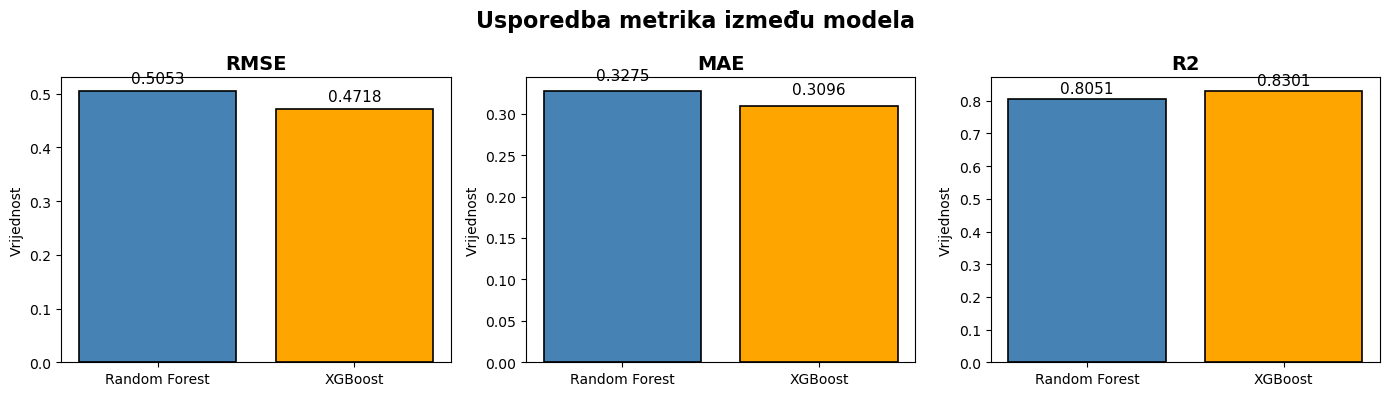

In [32]:
rf_metrics = {
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 4),
    'MAE': round(mean_absolute_error(y_test, y_pred_rf), 4),
    'R2': round(r2_score(y_test, y_pred_rf), 4)
}

xgb_metrics = {
    'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred_xgb)), 4),
    'MAE': round(mean_absolute_error(y_test, y_pred_xgb), 4),
    'R2': round(r2_score(y_test, y_pred_xgb), 4)
}

# Vizualizacija usporedbe metrika
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['RMSE', 'MAE', 'R2']
colors = ['steelblue', 'orange']
models = ['Random Forest', 'XGBoost']

for i, metric in enumerate(metrics):
    values = [rf_metrics[metric], xgb_metrics[metric]]
    bars = axes[i].bar(models, values, color=colors, edgecolor='black', linewidth=1.2)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Vrijednost')
    
    # Dodavanje vrijednosti iznad stupaca
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Usporedba metrika između modela', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Na grafu je prikazana usporedba metrika (RMSE, MAE i R²) između Random Forest i XGBoost modela
Svaki stupčasti dijagram prikazuje vrijednosti jedne metrike za oba modela

Vidimo da XGBoost ima niže vrijednosti RMSE i MAE šta znači da radi manje pogreške u predviđanju
Također ima i veći R² šta pokazuje da bolje objašnjava varijacije u cijenama kuća

Iz grafa se jasno vidi da je XGBoost model uspješniji i precizniji u odnosu na Random Forest mode

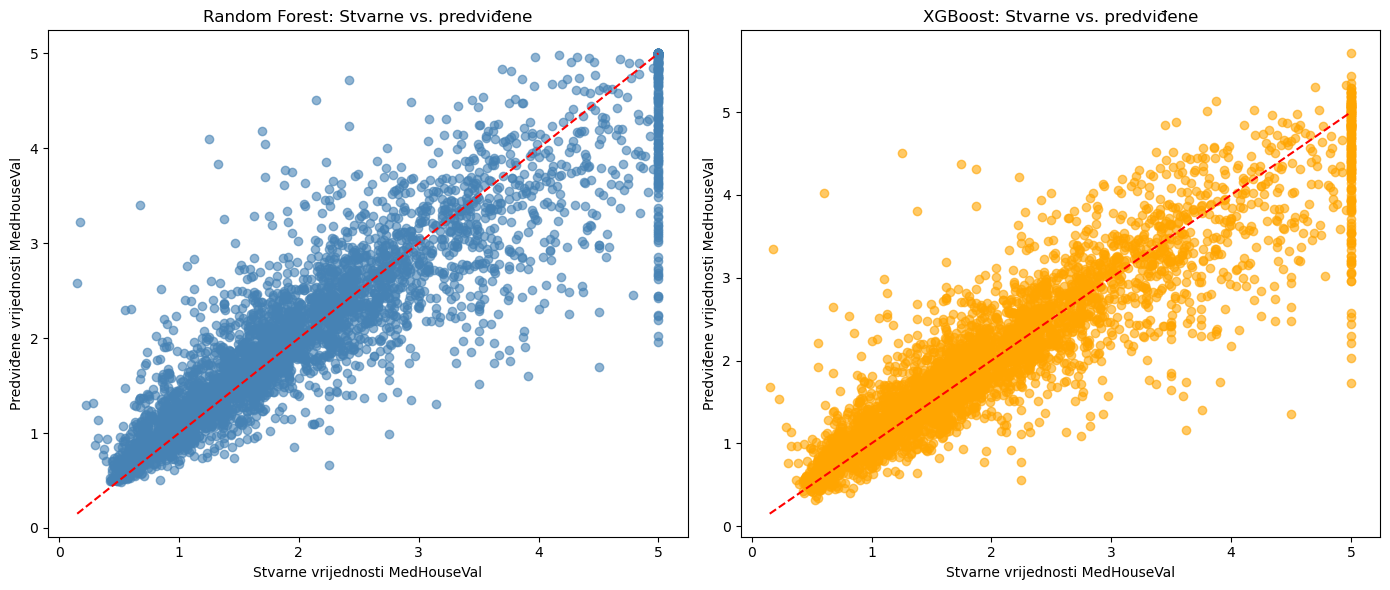

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  

# Scatter plot za Random Forest
axes[0].scatter(y_test, y_pred_rf, color='steelblue', alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
axes[0].set_xlabel("Stvarne vrijednosti MedHouseVal")
axes[0].set_ylabel("Predviđene vrijednosti MedHouseVal")
axes[0].set_title("Random Forest: Stvarne vs. predviđene")

# Scatter plot za XGBoost
axes[1].scatter(y_test, y_pred_xgb, color='orange', alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
axes[1].set_xlabel("Stvarne vrijednosti MedHouseVal")
axes[1].set_ylabel("Predviđene vrijednosti MedHouseVal")
axes[1].set_title("XGBoost: Stvarne vs. predviđene")

plt.tight_layout()  
plt.show()

Na grafu su prikazana dva scatter dijagrama koji uspoređuju stvarne i predviđene vrijednosti za oba modela
Svaka točka predstavlja jednu kuću, a crvena isprekidana linija označava idealno predviđanje

Možemo vidjeti da su točke kod XGBoost modela nešto bliže idealnoj liniji šta znači da daje preciznija predviđanja
Random Forest također dobro prati, ali ima nešto veća odstupanja

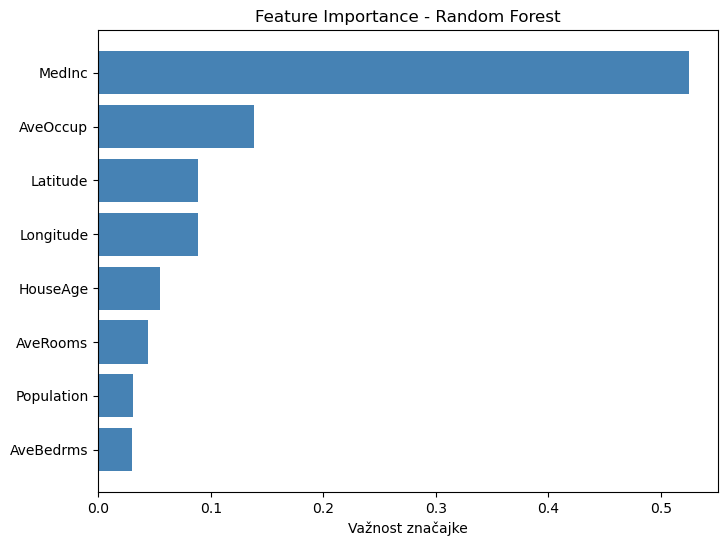

Top 5 najvažnijih značajki (Random Forest):
    značajka   važnost
0     MedInc  0.524871
5   AveOccup  0.138443
6   Latitude  0.088936
7  Longitude  0.088629
1   HouseAge  0.054593


In [21]:
# Random Forest značajke
feat_imp_rf = pd.DataFrame({
    'značajka': X.columns,
    'važnost': rf_model.feature_importances_
}).sort_values('važnost', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_rf['značajka'], feat_imp_rf['važnost'], color='steelblue')
plt.xlabel('Važnost značajke')
plt.title('Feature Importance - Random Forest')
plt.show()

print("Top 5 najvažnijih značajki (Random Forest):")
print(feat_imp_rf.nlargest(5, 'važnost'))

Graf pokazuje koliko je koja značajka važna za predviđanje cijene kuće u Random Forest modelu

Vidimo da je MedInc najvažniji šta znači da najviše utječe na predviđanje
Ovo sve model koristi ove podatke kada pokušava pogoditi cijenu kuće

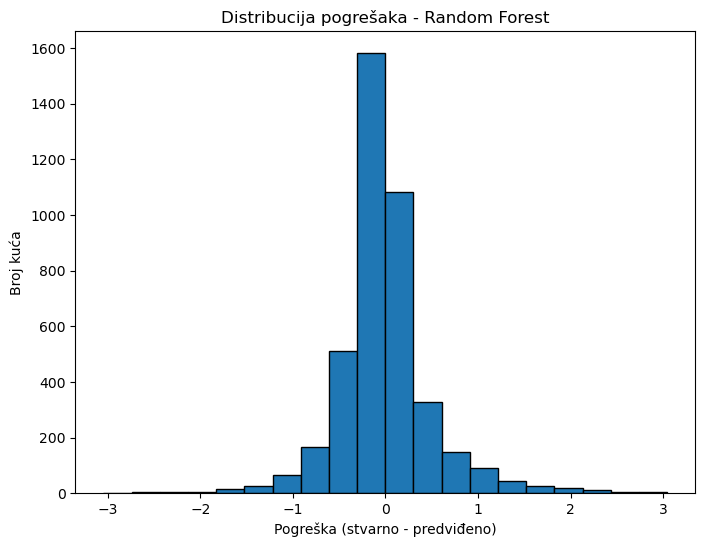

Osnovne statistike pogrešaka (Random Forest):
Srednja vrijednost: -0.01
Standardna devijacija: 0.51
Minimalna pogreška: -3.05
Maksimalna pogreška: 3.04


In [22]:
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(8,6))
plt.hist(residuals_rf, bins=20, edgecolor='black')
plt.xlabel("Pogreška (stvarno - predviđeno)")
plt.ylabel("Broj kuća")
plt.title("Distribucija pogrešaka - Random Forest")
plt.show()

print("Osnovne statistike pogrešaka (Random Forest):")
print("Srednja vrijednost:", round(residuals_rf.mean(),2))
print("Standardna devijacija:", round(residuals_rf.std(),2))
print("Minimalna pogreška:", round(residuals_rf.min(),2))
print("Maksimalna pogreška:", round(residuals_rf.max(),2))

Graf prikazuje pogreške predviđanja Random Forest modela, odnosno razliku između stvarnih i predviđenih vrijednosti
Većina pogrešaka je blizu nule, šta znači da model u većini slučajeva dobro pogađa cijene

Prosječna pogreška je oko -0.01 šta znači da model nema neko veliko odstupanje u jednom smjeru
Najveće pogreške su oko -3 do 3, ali takvih slučajeva ima malo

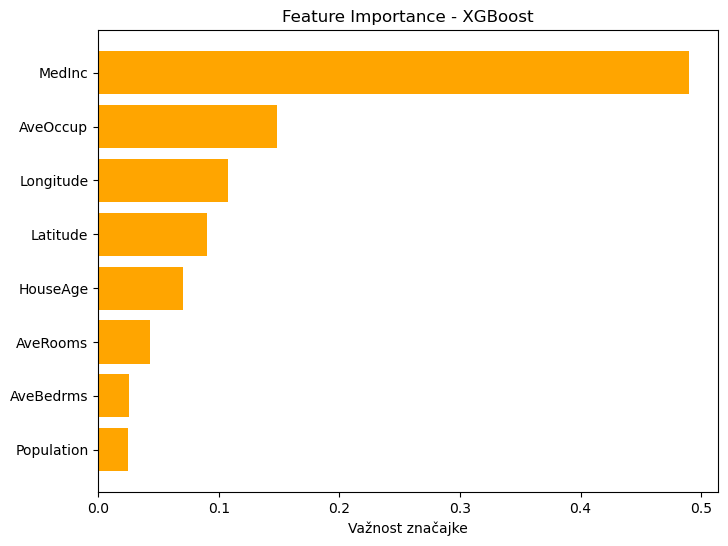

Top 5 najvažnijih značajki (XGBoost):
    značajka   važnost
0     MedInc  0.489623
5   AveOccup  0.148580
7  Longitude  0.107952
6   Latitude  0.090290
1   HouseAge  0.070058


In [33]:
# XGBoost značajke
feat_imp_xgb = pd.DataFrame({
    'značajka': X.columns,
    'važnost': xgb_model.feature_importances_
}).sort_values('važnost', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(feat_imp_xgb['značajka'], feat_imp_xgb['važnost'], color='orange')
plt.xlabel('Važnost značajke')
plt.title('Feature Importance - XGBoost')
plt.show()

print("Top 5 najvažnijih značajki (XGBoost):")
print(feat_imp_xgb.nlargest(5, 'važnost'))

Graf prikazuje koliko je koja značajka važna za predviđanje u XGBoost modelu

Vidimo da je MedInc opet najvažnija značajka šta znači da najviše utječe na predviđanje cijene kuće

Rezultati su vrlo slični kao kod Random Forest modela šta znači da oba modela koriste slične podatke za predviđanje